# Introduction:
In the `Base_line`notebook I constructed a linear regressor model, `ElasticNet`and `SGDRegressor`, so I can have a starting point and a benchmark comparison of any feature model. As it was shown in that Notebook, linear regression failed to estimate the target variable, `market_forward_excess_returns`. In this Notebook, I will implement a more robust family of models, `RandomForest`and `XGBRegressor`.

In [1]:
import numpy as np
import pandas as pd
import polars as pl
from pathlib import Path
from dataclasses import dataclass, asdict
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings

# Data classes helpers


In [2]:
@dataclass
class DatasetOutput:
    X_train: pl.DataFrame
    X_test: pl.DataFrame
    y_train: pl.Series
    y_test: pl.Series
    scaler: StandardScaler
    scaled: bool

    def __post_init__(self):
        '''Validates that each field holds the expected type, and that
        train/test splits are internally consistent.'''

        # --- type checks ---
        if not isinstance(self.X_train, pl.DataFrame):
            raise TypeError(
                f"X_train must be pl.DataFrame, got {type(self.X_train)}"
            )
        if not isinstance(self.X_test, pl.DataFrame):
            raise TypeError(
                f"X_test must be pl.DataFrame, got {type(self.X_test)}"
            )
        if not isinstance(self.y_train, pl.Series):
            raise TypeError(
                f"y_train must be pl.Series, got {type(self.y_train)}"
            )
        if not isinstance(self.y_test, pl.Series):
            raise TypeError(
                f"y_test must be pl.Series, got {type(self.y_test)}"
            )
        if not isinstance(self.scaler, StandardScaler):
            raise TypeError(
                f"scaler must be sklearn StandardScaler, got {type(self.scaler)}"
            )

        # --- shape / consistency checks ---
        if self.X_train.height != len(self.y_train):
            raise ValueError(
                f"X_train has {self.X_train.height} rows but y_train has "
                f"{len(self.y_train)} entries"
            )
        if self.X_test.height != len(self.y_test):
            raise ValueError(
                f"X_test has {self.X_test.height} rows but y_test has "
                f"{len(self.y_test)} entries"
            )
        if self.X_train.columns != self.X_test.columns:
            raise ValueError(
                f"X_train and X_test have mismatched columns: "
                f"{self.X_train.columns} vs {self.X_test.columns}"
            )

        # --- emptiness checks ---
        if self.X_train.height == 0:
            raise ValueError("X_train is empty")
        if self.X_test.height == 0:
            raise ValueError("X_test is empty")

        # --- scaler fitted check ---
        # A fitted StandardScaler has learned attributes ending in "_"
        # (mean_, scale_, var_). If they're absent, .fit() was never called.
        if not hasattr(self.scaler, "mean_"):
            warnings.warn(
                "scaler has not been fitted (missing 'mean_' attribute) — "
                "call scaler.fit(X_train) before constructing DatasetOutput"
            )

# Function helpers

In [3]:
def load_set(target_variable: str, file_name : str, n_exclude : int,
             shift_train_target: bool = False,) -> pl.DataFrame:
    """
    Loads and preprocesses the training dataset.
    Inputs:
    target_variable (str): variable that is the target of the predictions
    file_name (str) : the name of the file to be loaded
    n_exclude (int) : exclude the n last rows
    shift_train_target (bool): if True, shifts the target column up by
            one row, so that features at row t align with the target's
            value at row t+1, matching the feature/target alignment
            convention used in the test set. Defaults to False.
    
    Returns:
        pl.DataFrame: The preprocessed training DataFrame.
    """

    df = (pl.read_csv(DATA_PATH / file_name)
        .rename({target_variable:'target'})
        .with_columns(
            pl.exclude('date_id').cast(pl.Float64, strict=False) #cast to Float64 all columns except date
        )
        )
    total_exclude = max(n_exclude, 0)
    
    if shift_train_target:
        df = df.with_columns(pl.col("target").shift(-1).alias("target"))
        # the shift leaves the last row's target as null (no t+1 available);
        # fold that into the trailing-row exclusion so it's always dropped
        total_exclude += 1
        
    if total_exclude > 0:
        df = df.head(-total_exclude)
    return (df)


def split_dataset(train: pl.DataFrame, test: pl.DataFrame, features: list[str],
                 standard_scaler_bool: bool) -> DatasetOutput: 
    """
    Splits the data into features (X) and target (y), and scales the features.

    Args:
        train (pl.DataFrame): The processed training DataFrame.
        test (pl.DataFrame): The processed testing DataFrame.
        features (list[str]): List of features to used in model. 
        standard_scaler_bool (bool): Whether or not standard scaler is applied to the data.

    Returns:
        DatasetOutput: A dataclass containing the scaled feature sets, target series, and the fitted scaler.
    """
    # ========== For both, train and test, it drops date_id and target for the X features ===========
    # ========= and takes "target" for the Y (prediction) ===========================================
    X_train = train.drop(['date_id','target']) 
    y_train = train.get_column('target')
    
    X_test = test.drop(['date_id','target']) 
    y_test = test.get_column('target')

    if standard_scaler_bool:
        scaler = StandardScaler() 
        
        X_train_scaled_np = scaler.fit_transform(X_train)
        X_train = pl.from_numpy(X_train_scaled_np, schema=features)
        
        X_test_scaled_np = scaler.transform(X_test)
        X_test = pl.from_numpy(X_test_scaled_np, schema=features)
    else:
        scaler = StandardScaler() 
    
    
    return DatasetOutput(
        X_train = X_train,
        y_train = y_train, 
        X_test = X_test, 
        y_test = y_test,
        scaler = scaler,
        scaled = standard_scaler_bool,
    )

# Read input data

In [4]:
# ======================= Original dataset =======================
# DATA_PATH = Path("/kaggle/input/notebooks/sebastianvpal/data-exploration")
# path_train = ("train_split.csv")
# path_test = ("test_split.csv")
# path_val = ("val_split.csv")

# ================= Feature engineered dataset ==========================0
DATA_PATH = Path("/kaggle/input/notebooks/sebastianvpal/feature-engineering")
path_train = ("ds_train_no_noise.csv")
path_test = ("ds_test_no_noise.csv")
path_val = ("val_split.csv")

# ============ Reading data
target_variable_training = 'market_forward_excess_returns'
target_variable_test_val = 'lagged_forward_returns'
#===========
ds_train = load_set(target_variable=target_variable_training, 
                    file_name = path_train, n_exclude = 10, shift_train_target=True)
                        # align features(t) -> target(t+1), matching test set) 
#===========
ds_test = load_set(target_variable=target_variable_test_val, 
                    file_name = path_test, n_exclude=0) 
#===========
# ds_val = load_set(target_variable=target_variable_test_val, 
#                     file_name = path_val, n_exclude=0) 

According to the official documentation forward_returns and risk_free_rateare not available for the test dataset (train set only) I will drop these columns for the moment.

In [5]:
features_to_drop_train = ["forward_returns", "risk_free_rate"]
features_to_drop_test_val = ["lagged_risk_free_rate", "lagged_market_forward_excess_returns"]

ds_train = ds_train.drop(features_to_drop_train)
ds_test = ds_test.drop(features_to_drop_test_val)
# ds_val = ds_val.drop(features_to_drop_test_val)

# Generating training and test dataset

In [6]:
# creating list of features
FEATURES: list[str] = [col for col in ds_train.columns if col not in ['date_id', 'target']]

# creating the dataset. This data will be used for RandomForest, so standardscaler is NOT needed
dataset: DatasetOutput = split_dataset(train=ds_train, test=ds_test, features=FEATURES,
                                      standard_scaler_bool= False) 

X_train: pl.DataFrame = dataset.X_train
X_test: pl.DataFrame = dataset.X_test
y_train: pl.DataFrame = dataset.y_train
y_test: pl.DataFrame = dataset.y_test
scaler: StandardScaler = dataset.scaler 
scaled: bool = dataset.scaled

/tmp/ipykernel_16/1883765255.py:63: UserWarning: scaler has not been fitted (missing 'mean_' attribute) — call scaler.fit(X_train) before constructing DatasetOutput
  warnings.warn(


In [7]:
print(f"values were scaled: {scaled}")

values were scaled: False


**Given the amount of missing value and its position in the dataset (check data_exploration notebook) I will do imputation of the missing values adding a 0 and a new column 1:real data, 0: artificial, so the model can also distinguish from a real or imputed 0. This is also relevant for RandomForest as it doesn't manage NaN values natively**

In [8]:
imputer = SimpleImputer(strategy="constant", fill_value=0, add_indicator=True)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Implementing RandomForestRegressor with Randomized search CV

In [9]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import randint

In [10]:
@dataclass
class RandomForestCV_params():
    max_depth : np.ndarray #max depth of the forest
    min_samples_leaf: np.ndarray #minimum number of samples a leaf can have
    max_features: np.ndarray #how features are split each time
    n_estimators: np.ndarray #how many trees are considered

In [11]:
rng = np.random.default_rng()

RF_params = RandomForestCV_params(
    max_depth = randint(3, 12),
    min_samples_leaf = randint(10, 200),
    max_features = np.array(["sqrt", "log2", 0.3, 0.5], dtype=object),
    n_estimators = np.array([300, 500, 800]),
)

# == creating the RandomForest
rdf = RandomForestRegressor(oob_score=True, n_jobs=-1, random_state=0)# Check the final model using
#the out-of-Bag (OOB) samples using all available cores (n_jobs=-1)

# ===== As my data is a timeseries it is important to avoid any leakage during this search
# ==== for that, I will implement cross validation with awarness of this
time_cv = TimeSeriesSplit(n_splits=5)

# === Searching for the optimal values
RF_search = RandomizedSearchCV(
    rdf,
    param_distributions=asdict(RF_params),
    n_iter=30,
    cv=time_cv,
    scoring="r2",
    random_state=0,
    n_jobs=-1,
)   


RF_search.fit(X_train,y_train)

print("Best params:", RF_search.best_params_)
print("Best CV R²:", RF_search.best_score_)
print("OOB R² of refit best model:", RF_search.best_estimator_.oob_score_)

Best params: {'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 187, 'n_estimators': np.int64(500)}
Best CV R²: -0.0023852690835788116
OOB R² of refit best model: -0.0008472901497500462


# Evaluating the model predictions

In [12]:
# ========== Defining the randomforest with the best combination of parameters 
best_rf = RF_search.best_estimator_

y_pred_rf = best_rf.predict(X_test) #Making predictions

# Evaluating predictions
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test,y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)


print("==============================================")
print(f"Test R²:   {r2_rf:.4f}")
print("==============================================")
print(f"max(y_pred): {y_pred_rf.max():.6f}")
print(f"max(y_test): {y_test.max():.6f}")
print("==============================================")
print(f"min(y_pred): {y_pred_rf.min():.6f}")
print(f"min(y_test): {y_test.min():.6f}")
print("==============================================")
print(f"Test RMSE: {rmse_rf:.4f}")
print("==============================================")
print(f"Test MAE:  {mae_rf:.4f}")

Test R²:   -0.0429
max(y_pred): 0.002408
max(y_test): 0.040661
min(y_pred): -0.001043
min(y_test): -0.039754
Test RMSE: 0.0107
Test MAE:  0.0078


In [13]:
importances_rf = best_rf.feature_importances_
feature_names_out = imputer.get_feature_names_out(FEATURES)


feat_imp_rf = (
    pl.DataFrame({"feature": feature_names_out, "importance": importances_rf})
    .sort("importance", descending=True)
)
print("*"*15, " Most important variables","*"*15 )
print(feat_imp_rf[:40])

***************  Most important variables ***************
shape: (40, 2)
┌─────────┬────────────┐
│ feature ┆ importance │
│ ---     ┆ ---        │
│ str     ┆ f64        │
╞═════════╪════════════╡
│ S5      ┆ 0.094186   │
│ M4      ┆ 0.082121   │
│ V7      ┆ 0.06198    │
│ S2      ┆ 0.061141   │
│ E12     ┆ 0.057102   │
│ …       ┆ …          │
│ P2      ┆ 0.00771    │
│ I9      ┆ 0.007601   │
│ E10     ┆ 0.007439   │
│ P8      ┆ 0.00742    │
│ E20     ┆ 0.00738    │
└─────────┴────────────┘


In [14]:
feat_imp_asc = (
    pl.DataFrame({"feature": feature_names_out, "importance": importances_rf})
    .sort("importance", descending=False)
)
print("*"*15, " Less important variables","*"*15 )
print(feat_imp_asc[:90])

***************  Less important variables ***************
shape: (90, 2)
┌──────────────────────┬────────────┐
│ feature              ┆ importance │
│ ---                  ┆ ---        │
│ str                  ┆ f64        │
╞══════════════════════╪════════════╡
│ M13                  ┆ 0.0        │
│ missingindicator_E1  ┆ 0.0        │
│ missingindicator_E10 ┆ 0.0        │
│ missingindicator_E11 ┆ 0.0        │
│ missingindicator_E12 ┆ 0.0        │
│ …                    ┆ …          │
│ E6                   ┆ 0.004496   │
│ E5                   ┆ 0.004601   │
│ I7                   ┆ 0.004749   │
│ M17                  ┆ 0.004783   │
│ I3                   ┆ 0.005034   │
└──────────────────────┴────────────┘


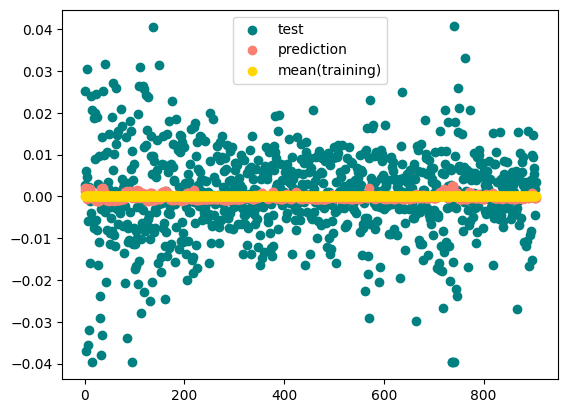

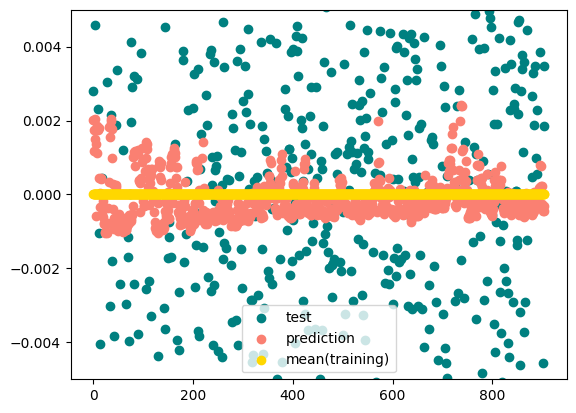

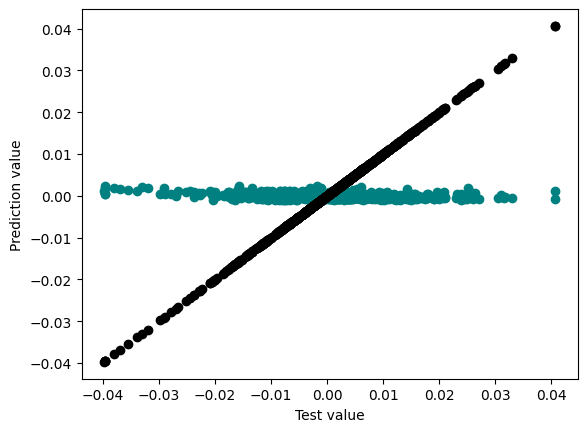

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
naive_pred = np.full_like(y_test, fill_value=y_train.mean())

n_pred = np.arange(len(list(y_test)))#number of prediction samples

ax.scatter(n_pred, y_test, label = 'test', color = 'teal')
ax.scatter(n_pred, list(y_pred_rf), label = 'prediction', color = 'salmon')
ax.scatter(n_pred, naive_pred, label = 'mean(training)', color = 'gold')

plt.legend()
plt.show()
#============ plot with zoom =============0
fig, ax = plt.subplots()

n_pred = np.arange(len(list(y_test)))#number of prediction samples

ax.scatter(n_pred, y_test, label = 'test', color = 'teal')
ax.scatter(n_pred, list(y_pred_rf), label = 'prediction', color = 'salmon')
ax.scatter(n_pred, naive_pred, label = 'mean(training)', color = 'gold')
ax.set_ylim(-0.005,0.005)
plt.legend()
plt.show()
# ============= Plot prediciton vs true
fig, ax = plt.subplots()

n_pred = np.arange(len(list(y_test)))#number of prediction samples

ax.scatter( y_test, y_pred_rf, color = 'teal')
ax.scatter( y_test, y_test, color = 'black')
ax.set_xlabel("Test value")
ax.set_ylabel("Prediction value")
plt.show()

# Implementation of HistGradientBosstingRegressor

X_train and X_test are computed again because imputation is not necessary for `HistGradientBoostingRegressor`. The model can handle `NaN` values automatically. This is because the model constructs a histogram of the data using 256 bins. Therefore, instead of splitting the trees based on the actual values, it splits the data using the histogram bins. This has the advantage of faster performance and automatic handling of NaN values.

In [16]:
from scipy.stats import randint, uniform
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

In [17]:
# creating list of features
FEATURES: list[str] = [col for col in ds_train.columns if col not in ['date_id', 'target']]

# creating the dataset. This data will be used for RandomForest, so standardscaler is NOT needed
dataset: DatasetOutput = split_dataset(train=ds_train, test=ds_test, features=FEATURES,
                                      standard_scaler_bool= False) 

X_train: pl.DataFrame = dataset.X_train
X_test: pl.DataFrame = dataset.X_test
y_train: pl.DataFrame = dataset.y_train
y_test: pl.DataFrame = dataset.y_test
scaler: StandardScaler = dataset.scaler 
scaled: bool = dataset.scaled

/tmp/ipykernel_16/1883765255.py:63: UserWarning: scaler has not been fitted (missing 'mean_' attribute) — call scaler.fit(X_train) before constructing DatasetOutput
  warnings.warn(


In [18]:
@dataclass
class HGBCV_params:
    max_depth: object          # distribution or array of candidate max_depth values
    min_samples_leaf: object   # distribution or array of candidate min_samples_leaf values
    max_leaf_nodes: object     # distribution or array of candidate max_leaf_nodes values
    learning_rate: object      # distribution or array of candidate learning_rate values
    max_iter: object        

In [19]:


   # array of candidate boosting-round counts

rng = np.random.default_rng()

HGB_params = HGBCV_params(
    max_depth=randint(3, 8),                 # shallower than RF — boosting fits residuals
    min_samples_leaf=randint(10, 200),
    max_leaf_nodes=randint(15, 63),           # HGBR's default is 31 — search around it
    learning_rate=uniform(0.01, 0.29),        # uniform(loc, scale) -> range [0.01, 0.30]
    max_iter=np.array([100, 300, 500]),       # replaces RF's n_estimators
)

# == creating the HistGradientBoostingRegressor
hgb = HistGradientBoostingRegressor(
    early_stopping=True,      # internally holds out validation data, stops adding trees
                               # once performance plateaus — a boosting-specific safeguard
    random_state=0,
)
# Note: no n_jobs / oob_score here — HGBR doesn't expose either;
# it parallelizes internally via OpenMP without an n_jobs knob, and has no OOB
# mechanism since it doesn't bootstrap (see explanation above).

# ===== As my data is a time series, avoid leakage during this search
time_cv = TimeSeriesSplit(n_splits=5)

# === Searching for the optimal values
HGB_search = RandomizedSearchCV(
    hgb,
    param_distributions=asdict(HGB_params),
    n_iter=30,
    cv=time_cv,
    scoring="r2",
    random_state=0,
    n_jobs=-1,   # parallelizes across the 30 x 5 = 150 CV fits, fine to keep here
)

HGB_search.fit(X_train, y_train)

print("Best params:", HGB_search.best_params_)
print("Best CV R² during CV:", HGB_search.best_score_)

# no OOB equivalent — instead, evaluate directly on the held-out test set
best_hgb = HGB_search.best_estimator_
test_r2_HGB = best_hgb.score(X_test, y_test)
print("Test R² of best model on test set:", test_r2_HGB)

Best params: {'learning_rate': np.float64(0.015449042126542991), 'max_depth': 3, 'max_iter': np.int64(100), 'max_leaf_nodes': 32, 'min_samples_leaf': 89}
Best CV R² during CV: -0.0026311030407751403
Test R² of best model on test set: -0.0077366618908134566


In [20]:
y_pred_HGB = best_hgb.predict(X_test) #Making predictions
rmse_HGB = np.sqrt(mean_squared_error(y_test,y_pred_HGB))
mae_HGB = mean_absolute_error(y_test, y_pred_HGB)

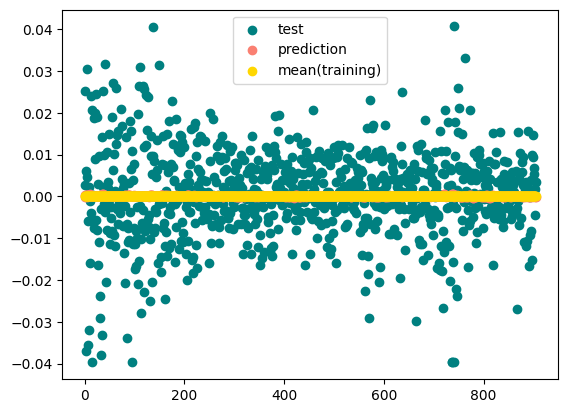

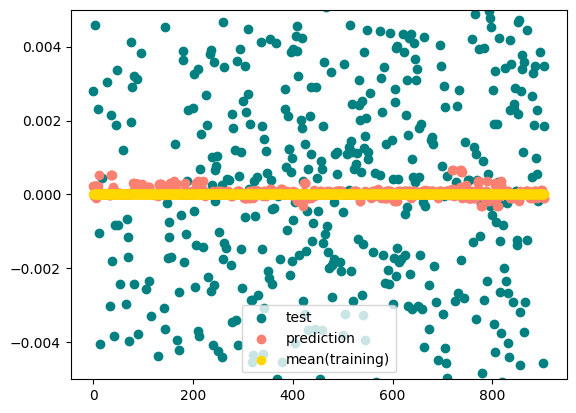

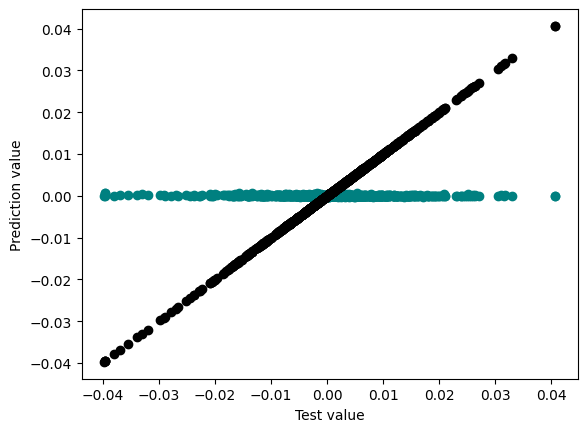

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
naive_pred = np.full_like(y_test, fill_value=y_train.mean())


n_pred = np.arange(len(list(y_test)))#number of prediction samples

ax.scatter(n_pred, y_test, label = 'test', color = 'teal')
ax.scatter(n_pred, list(y_pred_HGB), label = 'prediction', color = 'salmon')
ax.scatter(n_pred, naive_pred, label = 'mean(training)', color = 'gold')

plt.legend()
plt.show()
#============ plot with zoom =============0
fig, ax = plt.subplots()

n_pred = np.arange(len(list(y_test)))#number of prediction samples

ax.scatter(n_pred, y_test, label = 'test', color = 'teal')
ax.scatter(n_pred, list(y_pred_HGB), label = 'prediction', color = 'salmon')
ax.scatter(n_pred, naive_pred, label = 'mean(training)', color = 'gold')
ax.set_ylim(-0.005,0.005)
plt.legend()
plt.show()
# ============= Plot prediciton vs true
fig, ax = plt.subplots()

n_pred = np.arange(len(list(y_test)))#number of prediction samples

ax.scatter( y_test, y_pred_HGB, color = 'teal')
ax.scatter( y_test, y_test, color = 'black')
ax.set_xlabel("Test value")
ax.set_ylabel("Prediction value")
plt.show()

# Implementation of XGBoost

In [22]:
from xgboost import XGBRegressor

# Helper class for hyperparameters

In [23]:
from dataclasses import dataclass, asdict
import numpy as np
from scipy.stats import randint, uniform
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [24]:
@dataclass
class XGBCV_params:
    n_estimators: object #Number of trees
    learning_rate: object #Step size/shrinkage applied at each boosting iteration
    max_depth: object #How deep a tree can grow
    min_child_weight: object #Minimum sum of instance weights (Hessian) required in a child node
    gamma: object #Minimum loss reduction required to make a split
    subsample: object #Fraction of training instances (rows) randomly sampled for each tree
    colsample_bytree: object #Fraction of features (columns) randomly sampled for each tree
    reg_alpha: object #similar to Lasso (R1) in ElasticNet
    reg_lambda: object #similar to Ridge (R2) in ElasticNet

In [25]:
XGB_params = XGBCV_params( n_estimators=np.array([100,300,500]),
                         learning_rate=uniform(0.01,0.19),
                         max_depth=randint(3,8),
                         min_child_weight=np.array([1,2]),#randint(1,20),
                         gamma=np.array([0,1]),#uniform(0.0,0.5),
                         subsample=uniform(0.6,0.4), # samples from [0.6, 1.0]
                         colsample_bytree=uniform(0.6,0.4),
                         reg_alpha=uniform(0.0,1.0),
                         reg_lambda=uniform(0.5,1.5)) 

## Defining again train and test datasets 

In [26]:
# creating list of features
FEATURES: list[str] = [col for col in ds_train.columns if col not in ['date_id', 'target']]

# creating the dataset. This data will be used for RandomForest, so standardscaler is NOT needed
dataset: DatasetOutput = split_dataset(train=ds_train, test=ds_test, features=FEATURES,
                                      standard_scaler_bool= False) 

X_train: pl.DataFrame = dataset.X_train
X_test: pl.DataFrame = dataset.X_test
y_train: pl.DataFrame = dataset.y_train
y_test: pl.DataFrame = dataset.y_test
scaler: StandardScaler = dataset.scaler 
scaled: bool = dataset.scaled

/tmp/ipykernel_16/1883765255.py:63: UserWarning: scaler has not been fitted (missing 'mean_' attribute) — call scaler.fit(X_train) before constructing DatasetOutput
  warnings.warn(


## Creating XGBRegressor

In [27]:
xgb = XGBRegressor( objective="reg:pseudohubererror", #"reg:squarederror",
                  tree_method="hist", #histogram-based, matched HGBR approach
                  n_jobs=-1,
                  random_state=0)

In [28]:
# ====== Time-aware CV, avoiding time leakage ========
time_cv = TimeSeriesSplit(n_splits=5)

In [29]:
# ======= Searching for optimal values ========0
XGB_search = RandomizedSearchCV(
    xgb,
    param_distributions=asdict(XGB_params),
    n_iter=30,
    cv=time_cv,
    scoring="r2",
    random_state=0,
    n_jobs=-1,
)
# === Fitting the model inside the CV search wrapper ======
XGB_search.fit(X_train,y_train)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamm...
                                        'min_child_weight': array([1, 2]),
                                        'n_estimators': array([100, 300, 500]),
                                        'reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7dc07c1b7e60>,
                                        'reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7dc07c04fc20>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7dc06e998170>},
                   random_state=0, scoring='r2')

### Checkin best hyperparameters and defining best estimator

In [30]:
print(f"Best params: {XGB_search.best_params_}")
print("="*25)
print(f"Best CV R2: {XGB_search.best_score_}")
print("="*25)


Best params: {'colsample_bytree': np.float64(0.6000221427460034), 'gamma': np.int64(0), 'learning_rate': np.float64(0.0619729866149708), 'max_depth': 5, 'min_child_weight': np.int64(2), 'n_estimators': np.int64(100), 'reg_alpha': np.float64(0.9527916569719446), 'reg_lambda': np.float64(1.5312324145817229), 'subsample': np.float64(0.6862030708454234)}
Best CV R2: -0.0018139719963073731


In [31]:
#======== Defining best estimator ===========
best_xgb = XGB_search.best_estimator_
# ===== Making predictions with the best estimator on the test set =========
y_pred_xgb = best_xgb.predict(X_test)

# ======= computing metrics based on the predictions ===========
r2_xgb = r2_score(y_test,y_pred_xgb)
RMSE_xgb = np.sqrt(mean_squared_error(y_test,y_pred_xgb))
MAE_xgb = mean_absolute_error(y_test,y_pred_xgb)
print(f"Test R2: {r2_xgb:.4f}")
print("="*25)
print(f"Test RMSE: {RMSE_xgb:.6f}")
print("="*25)
print(f"Test MAE: {MAE_xgb:.6f}")
print("="*25)

Test R2: -0.0369
Test RMSE: 0.010684
Test MAE: 0.007775


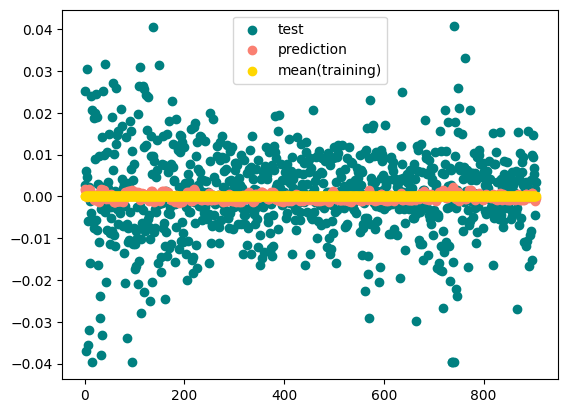

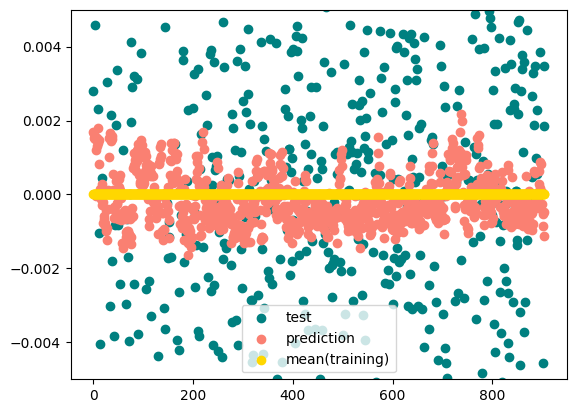

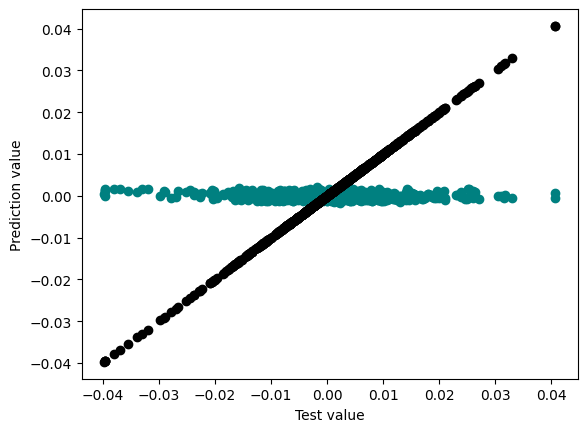

In [32]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
naive_pred = np.full_like(y_test, fill_value=y_train.mean())
# ==========================================
best_xgb = XGB_search.best_estimator_
y_pred = best_xgb.predict(X_test)
# ==========================================

n_pred = np.arange(len(list(y_test)))#number of prediction samples

ax.scatter(n_pred, y_test, label = 'test', color = 'teal')
ax.scatter(n_pred, list(y_pred_xgb), label = 'prediction', color = 'salmon')
ax.scatter(n_pred, naive_pred, label = 'mean(training)', color = 'gold')

plt.legend()
plt.show()
#============ plot with zoom =============0
fig, ax = plt.subplots()

n_pred = np.arange(len(list(y_test)))#number of prediction samples

ax.scatter(n_pred, y_test, label = 'test', color = 'teal')
ax.scatter(n_pred, list(y_pred_xgb), label = 'prediction', color = 'salmon')
ax.scatter(n_pred, naive_pred, label = 'mean(training)', color = 'gold')
ax.set_ylim(-0.005,0.005)
plt.legend()
plt.show()
# ============= Plot prediciton vs true
fig, ax = plt.subplots()

n_pred = np.arange(len(list(y_test)))#number of prediction samples

ax.scatter( y_test, y_pred_xgb, color = 'teal')
ax.scatter( y_test, y_test, color = 'black')
ax.set_xlabel("Test value")
ax.set_ylabel("Prediction value")
plt.show()

## Checking trees structure

In [33]:
print(best_xgb.get_booster().trees_to_dataframe())

      Tree  Node     ID Feature     Split   Yes     No Missing      Gain  \
0        0     0    0-0      M9 -0.136407   0-1    0-2     0-2  0.000042   
1        0     1    0-1     V13 -0.839510   0-3    0-4     0-4  0.000237   
2        0     2    0-2     E11  0.033730   0-5    0-6     0-5  0.000286   
3        0     3    0-3    Leaf       NaN   NaN    NaN     NaN -0.000000   
4        0     4    0-4      S8  0.954387   0-7    0-8     0-7  0.000147   
...    ...   ...    ...     ...       ...   ...    ...     ...       ...   
1223    99     6   99-6    Leaf       NaN   NaN    NaN     NaN -0.000000   
1224    99     7   99-7    Leaf       NaN   NaN    NaN     NaN -0.000000   
1225    99     8   99-8      P4  0.906415  99-9  99-10   99-10  0.000350   
1226    99     9   99-9    Leaf       NaN   NaN    NaN     NaN -0.000080   
1227    99    10  99-10    Leaf       NaN   NaN    NaN     NaN -0.000000   

            Cover  Category  
0     4863.205570       NaN  
1     2232.685790       NaN

## Checking feature importance from XGBRegressor

In [34]:
importances_xgb = best_xgb.feature_importances_
feat_imp_xgb = (pl.DataFrame({"feature":FEATURES, "importance":importances_xgb})
           .sort("importance",descending=True)
           )
print(feat_imp_xgb[:20])

shape: (20, 2)
┌─────────┬────────────┐
│ feature ┆ importance │
│ ---     ┆ ---        │
│ str     ┆ f32        │
╞═════════╪════════════╡
│ M7      ┆ 0.023761   │
│ E8      ┆ 0.020738   │
│ E10     ┆ 0.019548   │
│ E15     ┆ 0.019486   │
│ M9      ┆ 0.019409   │
│ …       ┆ …          │
│ P13     ┆ 0.017142   │
│ P7      ┆ 0.017101   │
│ E3      ┆ 0.016532   │
│ S3      ┆ 0.016518   │
│ D6      ┆ 0.016314   │
└─────────┴────────────┘


# Collecting metrics

## Statistics

In [35]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

columns_base = ['r_2', 'RMSE', 'MAE', 'mean', 'median', 'std', 'max', 'min', 'range']

def compute_stats(r2, rmse, mae, y_pred):
    return [r2, rmse, mae, np.mean(y_pred), np.median(y_pred),
            np.std(y_pred), np.max(y_pred), np.min(y_pred),
            np.max(y_pred) - np.min(y_pred)]

RF_stats   = compute_stats(r2_rf, rmse_rf, mae_rf, y_pred_rf)
HGBR_stats = compute_stats(test_r2_HGB, rmse_HGB, mae_HGB, y_pred_HGB)
XGBR_stats = compute_stats(r2_xgb, RMSE_xgb, MAE_xgb, y_pred_xgb)

# reference rows
naive_pred = np.full_like(y_test, fill_value=y_train.mean())
naive_r2_ = r2_score(y_test, naive_pred)
naive_rmse_ = np.sqrt(mean_squared_error(y_test, naive_pred))
naive_mae_ = mean_absolute_error(y_test, naive_pred)
naive_stats = compute_stats(naive_r2_, naive_rmse_, naive_mae_, naive_pred)

y_test_np = np.array(y_test)
y_test_stats = [np.nan, np.nan, np.nan, np.mean(y_test_np), np.median(y_test_np),
                np.std(y_test_np), np.max(y_test_np), np.min(y_test_np),
                np.max(y_test_np) - np.min(y_test_np)]

models = ['RF', 'HGBR', 'XGBR', 'Naive (train mean)', 'y_test (reference)']
all_stats = [RF_stats, HGBR_stats, XGBR_stats, naive_stats, y_test_stats]

df_statistics = pd.DataFrame(all_stats, columns=columns_base, index=models)
df_statistics['RMSE/std(y_test)'] = df_statistics['RMSE'] / np.std(y_test_np)

print(df_statistics)


                         r_2      RMSE       MAE      mean    median  \
RF                 -0.042884  0.010715  0.007765 -0.000153 -0.000336   
HGBR               -0.007737  0.010533  0.007631  0.000048  0.000023   
XGBR               -0.036859  0.010684  0.007775 -0.000173 -0.000330   
Naive (train mean) -0.003204  0.010509  0.007613  0.000016  0.000016   
y_test (reference)       NaN       NaN       NaN  0.000610  0.000693   

                             std       max       min     range  \
RF                  5.816867e-04  0.002408 -0.001043  0.003451   
HGBR                1.039148e-04  0.000675 -0.000298  0.000974   
XGBR                6.872732e-04  0.002168 -0.001626  0.003794   
Naive (train mean)  6.776264e-21  0.000016  0.000016  0.000000   
y_test (reference)  1.049223e-02  0.040661 -0.039754  0.080415   

                    RMSE/std(y_test)  
RF                          1.021217  
HGBR                        1.003861  
XGBR                        1.018263  
Naive (train m

## predictions

In [36]:
y_pred_dict = {
    'RF': y_pred_rf,
    'HGBR': y_pred_HGB,
    'XGBR': y_pred_xgb,
}

## Feature Importance

In [37]:
feat_imp_dict = {
    'RF': feat_imp_rf,
    'XGBR': feat_imp_xgb,
    # 'HGBR' intentionally omitted — HistGradientBoostingRegressor has no
    # native feature_importances_; would require permutation_importance instead,
    # which isn't directly comparable to RF/XGB's gain-based importances
}

In [38]:
import polars as pl

feat_imp_combined = (
    feat_imp_rf.rename({"importance": "importance_rf"})
    .join(
        feat_imp_xgb.rename({"importance": "importance_xgb"}),
        on="feature",
        how="full",   # keeps features present in only one model's importance list
        coalesce=True,
    )
    .sort("importance_rf", descending=True)
)

print(feat_imp_combined)

shape: (141, 3)
┌─────────────────────┬───────────────┬────────────────┐
│ feature             ┆ importance_rf ┆ importance_xgb │
│ ---                 ┆ ---           ┆ ---            │
│ str                 ┆ f64           ┆ f32            │
╞═════════════════════╪═══════════════╪════════════════╡
│ S5                  ┆ 0.094186      ┆ 0.009501       │
│ M4                  ┆ 0.082121      ┆ 0.012836       │
│ V7                  ┆ 0.06198       ┆ 0.017225       │
│ S2                  ┆ 0.061141      ┆ 0.011335       │
│ E12                 ┆ 0.057102      ┆ 0.013041       │
│ …                   ┆ …             ┆ …              │
│ missingindicator_V3 ┆ 0.0           ┆ null           │
│ missingindicator_V4 ┆ 0.0           ┆ null           │
│ missingindicator_V5 ┆ 0.0           ┆ null           │
│ missingindicator_V7 ┆ 0.0           ┆ null           │
│ missingindicator_V9 ┆ 0.0           ┆ null           │
└─────────────────────┴───────────────┴────────────────┘


# Writing outputs

In [39]:
test = False #True #this controls if this is a test or a version with output.

In [40]:
import os
if test:
    print("This is a test version, no output is saved")
else:
    OUT_DIR = "/kaggle/working"
    os.makedirs(OUT_DIR, exist_ok=True)
    
    df_statistics.to_csv(f"{OUT_DIR}/models_statistics_v2.csv", index=False)
    feat_imp_combined.write_csv(f"{OUT_DIR}/feat_imp_combined_v2.csv")
     # ===========================================================================
    
    print("="*20, f" {df_statistics} successfully written, shape : {df_statistics.shape} " ,"="*20)
    print("="*20, f" {feat_imp_combined} successfully written, shape : {feat_imp_combined.shape} ","="*20)

====================                           r_2      RMSE       MAE      mean    median  \
RF                 -0.042884  0.010715  0.007765 -0.000153 -0.000336   
HGBR               -0.007737  0.010533  0.007631  0.000048  0.000023   
XGBR               -0.036859  0.010684  0.007775 -0.000173 -0.000330   
Naive (train mean) -0.003204  0.010509  0.007613  0.000016  0.000016   
y_test (reference)       NaN       NaN       NaN  0.000610  0.000693   

                             std       max       min     range  \
RF                  5.816867e-04  0.002408 -0.001043  0.003451   
HGBR                1.039148e-04  0.000675 -0.000298  0.000974   
XGBR                6.872732e-04  0.002168 -0.001626  0.003794   
Naive (train mean)  6.776264e-21  0.000016  0.000016  0.000000   
y_test (reference)  1.049223e-02  0.040661 -0.039754  0.080415   

                    RMSE/std(y_test)  
RF                          1.021217  
HGBR                        1.003861  
XGBR                        1.0

In [41]:
df_statistics

,r_2,RMSE,MAE,mean,median,std,max,min,range,RMSE/std(y_test)
RF,-0.042884,0.010715,0.007765,-0.000153,-0.000336,5.816867e-04,0.002408,-0.001043,0.003451,1.021217
HGBR,-0.007737,0.010533,0.007631,0.000048,0.000023,1.039148e-04,0.000675,-0.000298,0.000974,1.003861
XGBR,-0.036859,0.010684,0.007775,-0.000173,-0.000330,6.872732e-04,0.002168,-0.001626,0.003794,1.018263
Naive (train mean),-0.003204,0.010509,0.007613,0.000016,0.000016,6.776264e-21,0.000016,0.000016,0.000000,1.001601
y_test (reference),NaN,NaN,NaN,0.000610,0.000693,1.049223e-02,0.040661,-0.039754,0.080415,NaN


In [42]:
feat_imp_combined

feature,importance_rf,importance_xgb
str,f64,f32
"""S5""",0.094186,0.009501
"""M4""",0.082121,0.012836
"""V7""",0.06198,0.017225
"""S2""",0.061141,0.011335
"""E12""",0.057102,0.013041
…,…,…
"""missingindicator_V3""",0.0,null
"""missingindicator_V4""",0.0,null
"""missingindicator_V5""",0.0,null


# Final Discussion

In this notebook, three different models were implemented: `RandomForestRegressor`, `HistGradientBoostingRegressor`, and `XGBRegressor`. In addition to these three models, a naive prediction was implemented as a baseline. This prediction consists of using the mean value of the training target as the prediction for every point in the test dataset.

Across the three models, and largely independent of the hyperparameter combinations tested, none achieved a prediction skill higher than the naive baseline. This suggests that, beyond model choice and hyperparameter search, feature engineering may be necessary to improve predictive performance. For instance, the `RandomForestRegressor` and `XGBRegressor` models expose a `feature_importances_` attribute, which shows that a considerable number of variables carry almost no importance, while a small subset of variables account for most of the importance. Note that `HistGradientBoostingRegressor` does not natively expose feature importances, and was therefore excluded from this comparison.

For this reason, the next step in this research will focus on feature engineering, guided by feature importance, variable correlations, and temporal behavior, to improve the models' predictive skill.